# Use this notebook to make training and testing data
This includes:
- LSST + Roman / Euclid data from simulations
- SPS data in multiple bands
- Narrow band data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os
import random

from sklearn.model_selection import train_test_split

# LSST + Roman from Cardinal simulation

In [2]:
# grab all pixels:
# Set the path to the directory you want to scan
directory =  "/global/cfs/cdirs/lsst/groups/PZ/Cardinal/parquet_files/test_cardinal_gold/"

# Get all folder names (not files) in that directory
folder_names = [
    name for name in os.listdir(directory)
    if os.path.isdir(os.path.join(directory, name))
]
print(folder_names)

selected_folders = random.sample(folder_names, 5)

print(selected_folders)

['69', '376', '427', '423', '80', '382', '441', '21', '27', '369', '75', '365', '70', '428', '78', '73', '341', '446', '371', '442', '430', '19', '97', '122', '277', '114', '17', '65', '378', '68', '429', '346', '342', '372', '443', '82', '435', '431', '115', '58', '26', '74', '347', '343', '77', '72', '373', '444', '432', '96', '112', '104', '99', '16', '64', '67', '348', '374', '30', '370', '81', '425', '350', '421', '113', '105', '101', '22', '25', '349', '345', '20', '28', '76', '375', '71', '434', '79', '426', '351', '422', '102', '440', '98', '18', '66']
['422', '80', '101', '346', '25']


In [3]:
root = "/global/cfs/cdirs/lsst/groups/PZ/Cardinal/parquet_files/test_cardinal_gold/"
for i, pixel in enumerate(selected_folders):
    fname = root + f"{pixel}/Chinchilla-3-triofile.pq"
    fin = pd.read_parquet(fname)
    # select 0.5% from each folder
    if i == 0:
        sample_sub = fin.sample(frac=0.005)
    if i > 0:
        df = fin.sample(frac=0.005)
        sample_sub = pd.concat([sample_sub, df], ignore_index=True)

In [4]:
sample_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199617 entries, 0 to 199616
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   galaxy_id                   199617 non-null  float64
 1   ra                          199617 non-null  float64
 2   dec                         199617 non-null  float64
 3   sedid                       199617 non-null  int64  
 4   size                        199617 non-null  float64
 5   Ellipticity_1               199617 non-null  float64
 6   Ellipticity_2               199617 non-null  float64
 7   mag_u_lsst                  199617 non-null  float64
 8   mag_g_lsst                  199617 non-null  float64
 9   mag_r_lsst                  199617 non-null  float64
 10  mag_i_lsst                  199617 non-null  float64
 11  mag_z_lsst                  199617 non-null  float64
 12  mag_y_lsst                  199617 non-null  float64
 13  Roman_Y106    

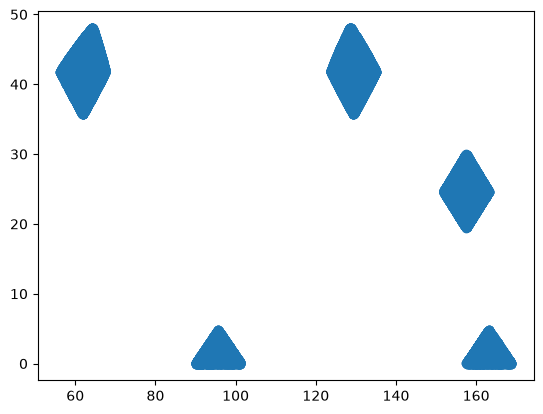

In [5]:
plt.scatter(sample_sub['ra'], sample_sub['dec'])

In [6]:
# now split the sample in train and test:
train_df, test_df = train_test_split(sample_sub, test_size=0.5, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [7]:
train_df

,galaxy_id,ra,dec,sedid,size,Ellipticity_1,Ellipticity_2,mag_u_lsst,mag_g_lsst,mag_r_lsst,...,mag_h_euclid_nisp,Roman_obs_Y106,Roman_obs_J129,Roman_obs_H158,Roman_obs_F184,Roman_obs_K213,totalHalfLightRadiusArcsec,TotalEllipticity,major,minor
0,2.500403e+10,62.991842,37.407889,354457,0.193099,0.020422,-0.134320,24.307806,23.524415,22.600840,...,20.913332,21.431393,21.207496,20.987964,20.897384,20.844912,0.193099,0.135863,0.523877,0.071176
1,8.000035e+10,155.645787,25.786150,277636,2.386807,0.073567,-0.161834,26.184450,24.605917,23.875922,...,22.682876,23.045327,22.871953,22.770905,22.629028,22.718481,2.386807,0.177771,5.660921,1.006346
2,2.500020e+10,65.607593,44.415818,238747,0.534080,-0.005524,0.160771,25.823205,24.982246,24.511870,...,23.899220,24.075416,23.982259,23.944229,23.888344,23.829144,0.534080,0.160866,1.331602,0.214209
3,8.000747e+10,155.908557,24.677196,361103,0.100579,0.095451,-0.341176,25.006742,24.815824,24.449504,...,22.454775,23.081614,22.780550,22.598817,22.402910,22.230771,0.100579,0.354276,0.168980,0.059866
4,1.010150e+11,130.562155,43.324761,471750,0.129327,0.056266,-0.104676,25.089903,24.932792,24.685016,...,22.095332,23.374455,22.642897,22.297774,22.014390,21.887604,0.129327,0.118840,0.375153,0.044583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99803,1.010043e+11,131.785396,38.949747,480141,0.219962,-0.105808,-0.015616,26.269882,25.515043,24.563903,...,23.812494,23.889841,23.863889,23.806275,23.817269,23.815954,0.219962,0.106954,0.672589,0.071936
99804,1.010067e+11,128.960443,42.572038,245450,1.172228,-0.093586,-0.171400,27.515532,26.873994,25.861853,...,24.052277,24.406692,24.259249,24.141905,24.025539,23.960200,1.172228,0.195285,2.652634,0.518021
99805,3.460000e+11,95.840118,0.872036,272207,0.841640,-0.266201,0.068309,24.374061,23.336839,22.718272,...,21.946050,22.177870,22.042666,21.994401,21.935194,21.852424,0.841640,0.274825,1.605454,0.441219
99806,3.460028e+11,94.400269,3.323846,467757,0.215578,0.131737,-0.279095,27.253635,26.748637,25.860219,...,24.126685,24.557444,24.416317,24.215371,24.100656,24.038828,0.215578,0.308624,0.388052,0.119762


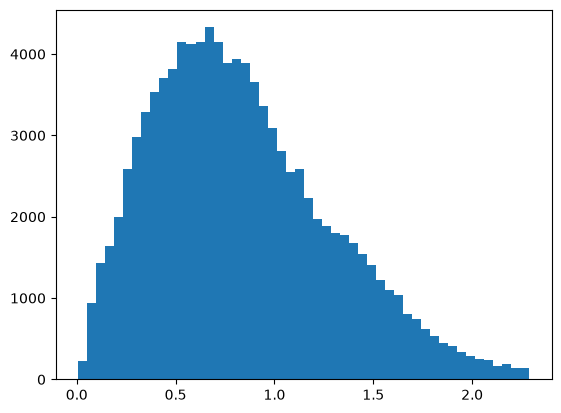

In [8]:
cc=plt.hist(train_df['redshift'], bins=50)

In [9]:
# save the catalogues:
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
train_df.to_parquet(saveroot + "train_100k.parquet", index=False)
test_df.to_parquet(saveroot + "test_100k.parquet", index=False)

### a larger subsample for Y1 degradation

In [10]:
root = "/global/cfs/cdirs/lsst/groups/PZ/Cardinal/parquet_files/test_cardinal_gold/"
for i, pixel in enumerate(selected_folders):
    fname = root + f"{pixel}/Chinchilla-3-triofile.pq"
    fin = pd.read_parquet(fname)
    # select 0.5% from each folder
    if i == 0:
        sample_sub_large = fin.sample(frac=0.025)
    if i > 0:
        df = fin.sample(frac=0.025)
        sample_sub_large = pd.concat([sample_sub_large, df], ignore_index=True)

In [11]:
sample_sub_large.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998083 entries, 0 to 998082
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   galaxy_id                   998083 non-null  float64
 1   ra                          998083 non-null  float64
 2   dec                         998083 non-null  float64
 3   sedid                       998083 non-null  int64  
 4   size                        998083 non-null  float64
 5   Ellipticity_1               998083 non-null  float64
 6   Ellipticity_2               998083 non-null  float64
 7   mag_u_lsst                  998083 non-null  float64
 8   mag_g_lsst                  998083 non-null  float64
 9   mag_r_lsst                  998083 non-null  float64
 10  mag_i_lsst                  998083 non-null  float64
 11  mag_z_lsst                  998083 non-null  float64
 12  mag_y_lsst                  998083 non-null  float64
 13  Roman_Y106    

In [12]:
# now split the sample in train and test:
train_df, test_df = train_test_split(sample_sub_large, test_size=0.5, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [13]:
# save the catalogues:
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
train_df.to_parquet(saveroot + "train_500k.parquet", index=False)
test_df.to_parquet(saveroot + "test_500k.parquet", index=False)

# add noise - LSST Y1 and Y10, Roman medium, Euclid wide

In [14]:
import h5py
import photerr
from photerr import LsstErrorModelV2, RomanMediumErrorModel, EuclidWideErrorModel

In [15]:
renameDict_lsst = {
    "u": "mag_u_lsst",
    "g": "mag_g_lsst",
    "r": "mag_r_lsst",
    "i": "mag_i_lsst",
    "z": "mag_z_lsst",
    "y": "mag_y_lsst",
}
renameDict_euclid = {
    #"VIS":,
    "Y": "mag_y_euclid_nisp", 
    "J": "mag_j_euclid_nisp",
    "H": "mag_h_euclid_nisp",
}
renameDict_roman = {
    "Y": "Roman_obs_Y106",
    "J": "Roman_obs_J129",
    "H": "Roman_obs_H158",
}

In [16]:
# load in the train and test files:
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
fname = saveroot + "train_100k.parquet"
training_data = pd.read_parquet(fname)
#training_data.info()

saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
fname = saveroot + "test_100k.parquet"
test_data = pd.read_parquet(fname)
#test_data.info()

In [17]:
# load in the train and test files:
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
fname = saveroot + "train_500k.parquet"
training_data_large = pd.read_parquet(fname)
#training_data.info()

saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
fname = saveroot + "test_500k.parquet"
test_data_large = pd.read_parquet(fname)
#test_data.info()

In [18]:
em_lsst_y1 = LsstErrorModelV2(renameDict = renameDict_lsst, nYrObs = 1, extendedType = 'gaap', aMin=1.5)
em_lsst_y10 = LsstErrorModelV2(renameDict = renameDict_lsst, nYrObs = 10, extendedType = 'gaap', aMin=1.5)
em_euclid = EuclidWideErrorModel(renameDict = renameDict_euclid)
em_roman =  RomanMediumErrorModel(renameDict = renameDict_roman)

In [19]:
# Y1
# build noisy training data
cols1 = list(renameDict_lsst.values())
cols1.append("major")
cols1.append("minor")
training_lsst_error_y1 = em_lsst_y1(training_data_large[cols1])

cols2 = list(renameDict_euclid.values())
training_euclid_error = em_euclid(training_data_large[cols2])

cols3 = list(renameDict_roman.values())
training_roman_error = em_roman(training_data_large[cols3])

# combine the data
training_drop= training_data_large.drop(columns=cols1 + cols2 + cols3)
training_error_y1 = pd.concat([training_drop, training_lsst_error_y1, training_euclid_error, training_roman_error], axis=1)

In [20]:
# Y10
cols1 = list(renameDict_lsst.values())
cols1.append("major")
cols1.append("minor")
training_lsst_error_y10 = em_lsst_y10(training_data[cols1])

cols2 = list(renameDict_euclid.values())
training_euclid_error = em_euclid(training_data[cols2])

cols3 = list(renameDict_roman.values())
training_roman_error = em_roman(training_data[cols3])

# combine the data
training_drop= training_data.drop(columns=cols1 + cols2 + cols3)
training_error_y10 = pd.concat([training_drop, training_lsst_error_y10, training_euclid_error, training_roman_error], axis=1)

In [21]:
training_error_y1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499041 entries, 0 to 499040
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   galaxy_id                   499041 non-null  float64
 1   ra                          499041 non-null  float64
 2   dec                         499041 non-null  float64
 3   sedid                       499041 non-null  int64  
 4   size                        499041 non-null  float64
 5   Ellipticity_1               499041 non-null  float64
 6   Ellipticity_2               499041 non-null  float64
 7   Roman_Y106                  499041 non-null  float64
 8   Roman_J129                  499041 non-null  float64
 9   Roman_H158                  499041 non-null  float64
 10  Roman_F184                  499041 non-null  float64
 11  Roman_K213                  499041 non-null  float64
 12  WISE_W1                     499041 non-null  float64
 13  WISE_W2       

In [22]:
# count i-band detections for Y1 and Y10, with i < 23 and i < 25.4
print("Y1")
count1 = sum(training_error_y1['mag_i_lsst'] < 23)
count2 = sum(training_error_y1['mag_i_lsst'] < 25.4)
print("i<23", count1, "i<25.4", count2)

print("Y10")
count1 = sum(training_error_y10['mag_i_lsst'] < 23)
count2 = sum(training_error_y10['mag_i_lsst'] < 25.4)
print("i<23", count1, "i<25.4", count2)

Y1
i<23 87088 i<25.4 443040
Y10
i<23 17250 i<25.4 92899


In [23]:
# Y1 test set:

# build noisy test data
cols1 = list(renameDict_lsst.values())
cols1.append("major")
cols1.append("minor")
test_lsst_error_y1 = em_lsst_y1(test_data_large[cols1])

cols2 = list(renameDict_euclid.values())
test_euclid_error = em_euclid(test_data_large[cols2])

cols3 = list(renameDict_roman.values())
test_roman_error = em_roman(test_data_large[cols3])

# combine the data
test_drop= test_data_large.drop(columns=cols1 + cols2 + cols3)
test_error_y1 = pd.concat([test_drop, test_lsst_error_y1, test_euclid_error, test_roman_error], axis=1)

In [24]:
# do the same for the test set:
# build noisy test data
cols1 = list(renameDict_lsst.values())
cols1.append("major")
cols1.append("minor")
test_lsst_error_y10 = em_lsst_y10(test_data[cols1])

cols2 = list(renameDict_euclid.values())
test_euclid_error = em_euclid(test_data[cols2])

cols3 = list(renameDict_roman.values())
test_roman_error = em_roman(test_data[cols3])

# combine the data
test_drop= test_data.drop(columns=cols1 + cols2 + cols3)
test_error_y10 = pd.concat([test_drop, test_lsst_error_y10, test_euclid_error, test_roman_error], axis=1)

In [25]:
# count i-band detections for Y1 and Y10, with i < 23 and i < 25.3
print("Y1")
count1 = sum(test_error_y1['mag_i_lsst'] < 23)
count2 = sum(test_error_y1['mag_i_lsst'] < 25.4)
print("i<23", count1, "i<25.4", count2)

print("Y10")
count1 = sum(test_error_y10['mag_i_lsst'] < 23)
count2 = sum(test_error_y10['mag_i_lsst'] < 25.4)
print("i<23", count1, "i<25.4", count2)

Y1
i<23 87390 i<25.4 443540
Y10
i<23 17132 i<25.4 92708


In [26]:
# save the y10 sample with the magnitude cut:
# save the catalogues:
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"

save_train = training_error_y10[training_error_y10['mag_i_lsst'] < 25.4]
save_test = test_error_y10[test_error_y10['mag_i_lsst'] < 25.4]

save_train.to_parquet(saveroot + "train_100k_noisy_y10_i25.4.parquet", index=False)
save_test.to_parquet(saveroot + "test_100k_noisy_y10_i25.4.parquet", index=False)

In [27]:
# save the y10 sample with the magnitude cut:
# save the catalogues:
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"

save_train = training_error_y1[training_error_y1['mag_i_lsst'] < 23]
save_test = test_error_y1[test_error_y1['mag_i_lsst'] < 23]

save_train.to_parquet(saveroot + "train_100k_noisy_y1_i23.parquet", index=False)
save_test.to_parquet(saveroot + "test_100k_noisy_y1_i23.parquet", index=False)

## noisify the pop-cosmos data in the same way

In [28]:
# let's also load pre-training data:
f = h5py.File("/pscratch/sd/q/qhang/pop-cosmos-data/mock_catalog_Ch1_26.h5", "r")

# Load the full arrays into memory ONCE (this is the only disk read)
fluxes_rubin = f['fluxes_rubin'][:]      # numpy array, all in RAM
fluxes_roman = f['fluxes_roman'][:]
sps_params   = f['sps_parameters'][:]

pre_training_popcosmos = {}
# collect ugrizy
# first, select samples with i < 25.5
ind = -2.5*np.log10(fluxes_rubin[:,3]) < 25.5
for i, band in enumerate("ugrizy"):
    pre_training_popcosmos[f'mag_{band}_lsst'] = -2.5*np.log10(fluxes_rubin[ind,i])
    
for i, band in zip([2,3,5],"YJH"):
    pre_training_popcosmos[f"mag_{band}_roman"] = -2.5*np.log10(fluxes_roman[ind,i])
    
pre_training_popcosmos["redshift"] = sps_params[ind,-1]

pre_training_popcosmos = pd.DataFrame(pre_training_popcosmos)
# compare with the test set to see if we cover the full feature space
print(len(pre_training_popcosmos))

PermissionError: [Errno 13] Unable to synchronously open file (unable to open file: name = '/pscratch/sd/q/qhang/pop-cosmos-data/mock_catalog_Ch1_26.h5', errno = 13, error message = 'Permission denied', flags = 0, o_flags = 0)

In [ ]:
renameDict_lsst = {
    "u": "mag_u_lsst",
    "g": "mag_g_lsst",
    "r": "mag_r_lsst",
    "i": "mag_i_lsst",
    "z": "mag_z_lsst",
    "y": "mag_y_lsst",
}
renameDict_roman = {
    "Y": "mag_Y_roman",
    "J": "mag_J_roman",
    "H": "mag_H_roman",
}

In [ ]:
# let's degrade this to lsst y10 and y1:
em_lsst_y1 = LsstErrorModelV2(renameDict = renameDict_lsst, nYrObs = 1, extendedType = 'point')
em_lsst_y10 = LsstErrorModelV2(renameDict = renameDict_lsst, nYrObs = 10, extendedType = 'point')
em_roman =  RomanMediumErrorModel(renameDict = renameDict_roman)

cols1 = list(renameDict_lsst.values())
pretraining_lsst_error_y1 = em_lsst_y1(pre_training_popcosmos[cols1])
pretraining_lsst_error_y10 = em_lsst_y10(pre_training_popcosmos[cols1])

cols3 = list(renameDict_roman.values())
pretraining_roman_error = em_roman(pre_training_popcosmos[cols3])

# combine the data
pretraining_drop= pre_training_popcosmos.drop(columns=cols1 + cols3)
pretraining_error_y1 = pd.concat([pretraining_drop, pretraining_lsst_error_y1, pretraining_roman_error], axis=1)
pretraining_error_y10 = pd.concat([pretraining_drop, pretraining_lsst_error_y10, pretraining_roman_error], axis=1)

In [ ]:
pretraining_error_y1

In [ ]:
pretraining_error_y10

In [ ]:
# save these files:
fname = "/pscratch/sd/q/qhang/pop-cosmos-data/mock_catalog_Ch1_26.degrade_lsst_y1.parquet"
pretraining_error_y1.to_parquet(fname, index=False)

fname = "/pscratch/sd/q/qhang/pop-cosmos-data/mock_catalog_Ch1_26.degrade_lsst_y10.parquet"
pretraining_error_y10.to_parquet(fname, index=False)

# sub-select in colour space (tasket 2)

- options:
    1. take the same selection by running through the cardinal spec degrader -> we will get pretty much the same sample
    3. match colour redshift features using a SOM (can say things like we match to the distribution)

In [29]:
# run these selectors on cardinal
from rail.creation.degraders import spectroscopic_selections
from rail.creation.degraders.spectroscopic_selections import SpecSelection_zCOSMOS, SpecSelection_DEEP2_LSST, SpecSelection_VVDSf02,SpecSelection_DESI_LRG, SpecSelection_DESI_ELG_LOP, SpecSelection_DESI_BGS

In [30]:
# load the large training sample
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
raw = pd.read_parquet(saveroot + "train_500k.parquet")

# degrade to Y10 depth
cols1 = list(renameDict_lsst.values())
cols1.append("major")
cols1.append("minor")
training_lsst_error_y10 = em_lsst_y10(raw[cols1])

cols2 = list(renameDict_euclid.values())
training_euclid_error = em_euclid(raw[cols2])

cols3 = list(renameDict_roman.values())
training_roman_error = em_roman(raw[cols3])

# combine the data
training_drop= raw.drop(columns=cols1 + cols2 + cols3)
training_error_y10 = pd.concat([training_drop, training_lsst_error_y10, training_euclid_error, training_roman_error], axis=1)

save_train = training_error_y10[training_error_y10['mag_i_lsst'] < 25.4]

print(len(save_train))

464582


In [31]:
# load in the degraded training dataset:
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
train_y10 = pd.read_parquet(saveroot + "train_100k_noisy_y10_i25.4.parquet")
train_y1 = pd.read_parquet(saveroot + "train_100k_noisy_y1_i23.parquet")

In [32]:
colnames = {
    "redshift":"redshift",
    "u": "mag_u_lsst",
    "g": "mag_g_lsst",
    "r": "mag_r_lsst",
    "i": "mag_i_lsst",
    "z": "mag_z_lsst",
    "y": "mag_y_lsst",
    "W1": "WISE_W1",
    "W2": "WISE_W2",
}

In [33]:
# deep2_lsst:
deep2lsst_selector = SpecSelection_DEEP2_LSST.make_stage(downsample=False, colnames = colnames)

deep2_lsst_data = deep2lsst_selector(save_train)
print(len(deep2_lsst_data.data))

desibgs_selector = SpecSelection_DESI_BGS.make_stage(downsample=False, colnames = colnames)

desibgs_data = desibgs_selector(save_train)
print(len(desibgs_data.data))

desilrg_selector = SpecSelection_DESI_LRG.make_stage(downsample=False, colnames = colnames)

desilrg_data = desilrg_selector(save_train)
print(len(desilrg_data.data))

desielg_selector = SpecSelection_DESI_ELG_LOP.make_stage(downsample=False, colnames = colnames)

desielg_data = desielg_selector(save_train)
print(len(desielg_data.data))

vvds_selector = SpecSelection_VVDSf02.make_stage(downsample=False, colnames = colnames)

vvds_data = vvds_selector(save_train)
print(len(vvds_data.data))

zcosmos_selecter = SpecSelection_zCOSMOS.make_stage(downsample=False, colnames=colnames)
zcosmos_data = zcosmos_selecter(save_train)
print(len(zcosmos_data.data))

2026-09-15 09:12:12 [info     ] Inserting handle into data store.  input: None, SpecSelection_DEEP2_LSST
2026-09-15 09:12:12 [info     ] Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DEEP2_LSST
37171
2026-09-15 09:12:12 [info     ] Inserting handle into data store.  input: None, SpecSelection_DESI_BGS
2026-09-15 09:12:12 [info     ] Applying the selection for DESI BGS (r < 19.5)...
2026-09-15 09:12:12 [info     ] Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DESI_BGS
1850
2026-09-15 09:12:12 [info     ] Inserting handle into data store.  input: None, SpecSelection_DESI_LRG
2026-09-15 09:12:12 [info     ] Applying the selection for DESI LRG (simplified cuts)...
2026-09-15 09:12:12 [info     ] Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DESI_LRG
6588
2026-09-15 09:12:12 [info     ] Inserting handle into data store.  input: None, SpecSelection_DESI_ELG_LOP
2026-09-15 09:12:12 [info     ] A

In [34]:
# merge:
from functools import reduce

subs = [deep2_lsst_data, desibgs_data, desilrg_data, desielg_data, vvds_data, zcosmos_data]
idx = reduce(lambda a, b: a.union(b), [s.data.index for s in subs])
merged_specsel_y10 = save_train.loc[idx]
# downsample to 100k
merged_specsel_y10 = merged_specsel_y10.sample(n=100000, random_state=42) 

Text(0.5, 0, 'redshift')

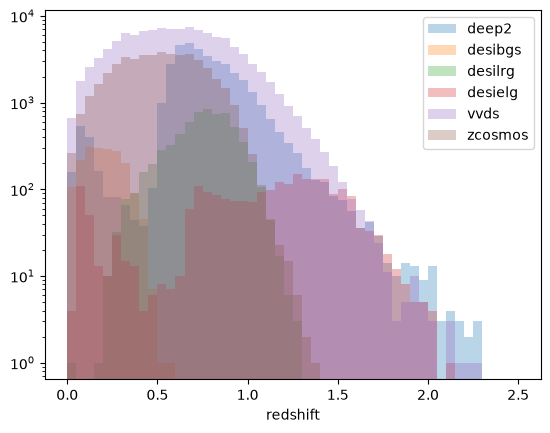

In [35]:
# plot their redshift distribution:
for dataset, tag in zip((deep2_lsst_data, desibgs_data, desilrg_data, desielg_data, vvds_data, zcosmos_data),
                        ('deep2', 'desibgs', 'desilrg', 'desielg', 'vvds', 'zcosmos')):
    red = dataset.data['redshift']
    cc = plt.hist(red, bins=50, range=[0,2.5], alpha=0.3, label=tag)
plt.yscale('log')
plt.legend()
plt.xlabel("redshift")

100000


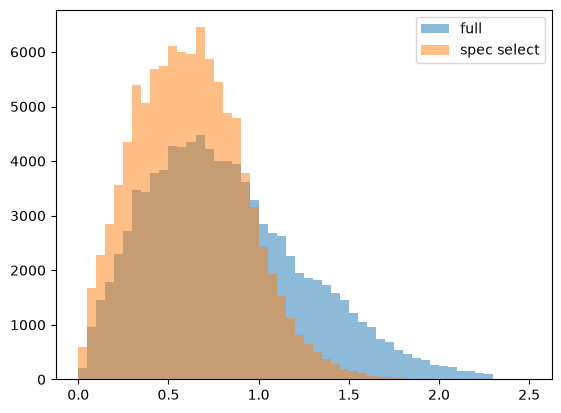

In [36]:
red = train_y10['redshift']
cc = plt.hist(red, bins=50, range=[0,2.5], label='full', alpha=0.5)

red = merged_specsel_y10['redshift']
cc = plt.hist(red, bins=50, range=[0,2.5], label='spec select', alpha=0.5)
plt.legend()
print(len(red))
#plt.yscale('log')

In [38]:
# let's save this for 10 - year 
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
fname = saveroot + "train_100k_noisy_y10_i25.4.SpecSelect.parquet"
merged_specsel_y10.to_parquet(fname)

In [39]:
# deep2_lsst:
deep2lsst_selector = SpecSelection_DEEP2_LSST.make_stage(downsample=False, colnames = colnames)

deep2_lsst_data = deep2lsst_selector(train_y1)
print(len(deep2_lsst_data.data))

desibgs_selector = SpecSelection_DESI_BGS.make_stage(downsample=False, colnames = colnames)

desibgs_data = desibgs_selector(train_y1)
print(len(desibgs_data.data))

desilrg_selector = SpecSelection_DESI_LRG.make_stage(downsample=False, colnames = colnames)

desilrg_data = desilrg_selector(train_y1)
print(len(desilrg_data.data))

desielg_selector = SpecSelection_DESI_ELG_LOP.make_stage(downsample=False, colnames = colnames)

desielg_data = desielg_selector(train_y1)
print(len(desielg_data.data))

vvds_selector = SpecSelection_VVDSf02.make_stage(downsample=False, colnames = colnames)

vvds_data = vvds_selector(train_y1)
print(len(vvds_data.data))

zcosmos_selecter = SpecSelection_zCOSMOS.make_stage(downsample=False, colnames=colnames)
zcosmos_data = zcosmos_selecter(train_y1)
print(len(zcosmos_data.data))

2026-09-15 09:12:44 [info     ] Inserting handle into data store.  input: None, SpecSelection_DEEP2_LSST
2026-09-15 09:12:44 [info     ] Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DEEP2_LSST
28176
2026-09-15 09:12:44 [info     ] Inserting handle into data store.  input: None, SpecSelection_DESI_BGS
2026-09-15 09:12:44 [info     ] Applying the selection for DESI BGS (r < 19.5)...
2026-09-15 09:12:44 [info     ] Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DESI_BGS
1852
2026-09-15 09:12:44 [info     ] Inserting handle into data store.  input: None, SpecSelection_DESI_LRG
2026-09-15 09:12:44 [info     ] Applying the selection for DESI LRG (simplified cuts)...
2026-09-15 09:12:44 [info     ] Inserting handle into data store.  output: inprogress_output.pq, SpecSelection_DESI_LRG
5792
2026-09-15 09:12:44 [info     ] Inserting handle into data store.  input: None, SpecSelection_DESI_ELG_LOP
2026-09-15 09:12:44 [info     ] A

In [40]:
# merge:
from functools import reduce

subs = [deep2_lsst_data, desibgs_data, desilrg_data, desielg_data, vvds_data, zcosmos_data]
idx = reduce(lambda a, b: a.union(b), [s.data.index for s in subs])
merged_specsel_y1 = train_y1.loc[idx]

73763


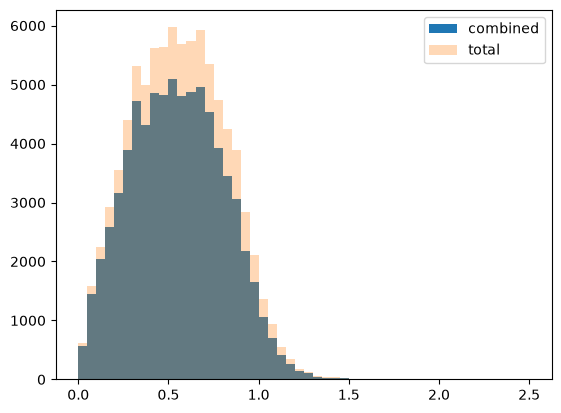

In [41]:
red = merged_specsel_y1['redshift']
cc = plt.hist(red, bins=50, range=[0,2.5], label='combined')
red2 = train_y1['redshift']
cc = plt.hist(red2, bins=50, range=[0,2.5], label='total',alpha=0.3)
plt.legend()
print(len(red))
#plt.yscale('log')

In [42]:
# let's save this for 10 - year 
saveroot = "/pscratch/sd/j/jaimerz/cnnpz/cardinal/"
fname = saveroot + "train_100k_noisy_y1_i23.SpecSelect.parquet"
merged_specsel_y1.to_parquet(fname)

In [43]:
import h5py

In [46]:
saveroot = "/pscratch/sd/j/jaimerz/pz_challenge_data/"
sim = "cardinal"
Yrs = [1, 10]
train_dataset_taskset2 = {}
train_dataset_taskset2[sim] = {}
for Yr in Yrs:
    fname = saveroot + f"pz_challenge_taskset_2_{sim}_training_{Yr}yr.hdf5"
    with h5py.File(fname, 'r') as f:
        data = {key: f[key][:] for key in f.keys()}
    train_dataset_taskset2[sim][Yr] = pd.DataFrame(data)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/pscratch/sd/j/jaimerz/pz_challenge_data/pz_challenge_taskset_2_cardinal_training_1yr.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
red =train_dataset_taskset2[sim][1]['redshift']
cc = plt.hist(red, bins=50, range=[0,2.5], label='combined')

In [ ]:
red =train_dataset_taskset2[sim][10]['redshift']
cc = plt.hist(red, bins=50, range=[0,2.5], label='combined')

In [ ]:
# to get around 100k, need 4x data: